In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from abc import abstractmethod
from trackml.utils import decode_particle_id

In [6]:

class IterBase:
    """Iterable Base class for TrackML and ACTS datasets.

    Attributes:
        folder (Path): directory containing dataset.
    """

    def __init__(self, dataset_dir, folder="train", dataset=None, **kwargs):
        self.path = Path(dataset_dir) / folder
        self.available_events = self._event_range()

        # Add kwargs to the class
        for key, value in kwargs.items():
            setattr(self, key, value)

    def _event_range(self):

        event_numbers = []
        for file in self.path.glob("*"):
            event_numbers.append(file.stem.split("-")[0])

        if not event_numbers:
            raise FileNotFoundError(
                "Uh-oh! Looks like there data files are missing ..."
            )

        return sorted(list(set(event_numbers)))

    @abstractmethod
    def _preprocessor(self, event: str):
        """preprocessing logic."""
        raise NotImplementedError

    @abstractmethod
    def _load_event(self, eventfiles):
        """loading logic."""
        raise NotImplementedError

    def __iter__(self):
        total_events = len(self.available_events)
        iter_start = 0
        iter_end = total_events

        for i in range(iter_start, iter_end):
            event_files = self._load_event(self.available_events[i])
            processed_data = self._preprocessor(event_files)
            yield from processed_data


########################################### streamline datasets:


class TrackMLDataset(IterBase):
    """Iterable class for TrackML"""

    def _load_event(self, event_prefix):
        self.event = event_prefix
        hits = self.path / f"{event_prefix}-hits.csv"
        particles = self.path / f"{event_prefix}-particles.csv"
        cells = self.path / f"{event_prefix}-cells.csv"
        truth = self.path / f"{event_prefix}-truth.csv"
        return (
            pd.read_csv(hits),
            pd.read_csv(cells),
            pd.read_csv(particles),
            pd.read_csv(truth),
        )

    def _preprocessor(self, eventfiles):
        # Get kwargs min_hits if available
        min_hits = getattr(self, "min_hits", 0)

        hits, _, particles, truth = eventfiles
        # Get kwargs keep_secondaries if available
        keep_secondaries = getattr(self, "keep_secondaries", True)
        # if not keep_secondaries:
        #     particles = decode_particle_id(particles)

        particles = particles[particles["nhits"] >= min_hits]

        merged_df = pd.merge(truth, particles, on="particle_id")
        merged_df = pd.merge(merged_df, hits, on="hit_id")
        merged_df["pT"] = np.sqrt(merged_df["px"] ** 2 + merged_df["py"] ** 2)

        # Get kwargs min_pt and max_pt if available
        min_pt = getattr(self, "min_pt", 0)
        max_pt = getattr(self, "max_pt", np.inf)

        merged_df = merged_df[(merged_df["pT"] >= min_pt) & (merged_df["pT"] <= max_pt)]
        if not keep_secondaries:
            # print(np.unique(merged_df["secondary_id"]))
            secondary_selection = (np.abs(merged_df["vx"]) >= 1) | (np.abs(merged_df["vy"]) >= 1)
            # print(np.sum(merged_df[~secondary_selection]["secondary_id"] == 0))
            # secondary_selection = merged_df["secondary_id"] != 0
            merged_df = merged_df[~secondary_selection]
            # print(np.unique(merged_df["secondary_id"]))
            # print()


        p = np.sqrt(merged_df["px"] ** 2 + merged_df["py"] ** 2 + merged_df["pz"] ** 2)
        merged_df["peta"] = np.arctanh(merged_df["pz"] / p)
        # data['{}pphi'.format(prefix)] = np.arctan2(py, px)

        # Get kwargs min_abs_eta and max_abs_eta if available
        min_abs_eta = getattr(self, "min_abs_eta", 0)
        max_abs_eta = getattr(self, "max_abs_eta", np.inf)

        merged_df = merged_df[
            (np.abs(merged_df["peta"]) >= min_abs_eta)
            & (np.abs(merged_df["peta"]) <= max_abs_eta)
        ]

        grouped = merged_df.groupby("particle_id")

        for _, group in grouped:
            yield group

In [7]:
dataset = TrackMLDataset('Data/Tml/train_1', folder="test", min_hits=3, min_pt=0.5, max_pt=10, keep_secondaries=False)
dataset = TrackMLDataset('Data/Tml/train_1', folder="test", min_hits=3, min_pt=0.5, max_pt=10, keep_secondaries=False, max_abs_eta=1)

# Get all the events
for event in dataset:
    print(event.columns)
    break

Index(['hit_id', 'particle_id', 'tx', 'ty', 'tz', 'tpx', 'tpy', 'tpz',
       'weight', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'q', 'nhits', 'x', 'y',
       'z', 'volume_id', 'layer_id', 'module_id', 'pT', 'peta'],
      dtype='object')


In [8]:
all_events = []
for event_id, event in enumerate(dataset):
    print(f"Event: {event_id}")
    # if event_id > 100000:
    #     break
    all_events.append(event)

all_events = pd.concat(all_events)


Event: 0
Event: 1
Event: 2
Event: 3
Event: 4
Event: 5
Event: 6
Event: 7
Event: 8
Event: 9
Event: 10
Event: 11
Event: 12
Event: 13
Event: 14
Event: 15
Event: 16
Event: 17
Event: 18
Event: 19
Event: 20
Event: 21
Event: 22
Event: 23
Event: 24
Event: 25
Event: 26
Event: 27
Event: 28
Event: 29
Event: 30
Event: 31
Event: 32
Event: 33
Event: 34
Event: 35
Event: 36
Event: 37
Event: 38
Event: 39
Event: 40
Event: 41
Event: 42
Event: 43
Event: 44
Event: 45
Event: 46
Event: 47
Event: 48
Event: 49
Event: 50
Event: 51
Event: 52
Event: 53
Event: 54
Event: 55
Event: 56
Event: 57
Event: 58
Event: 59
Event: 60
Event: 61
Event: 62
Event: 63
Event: 64
Event: 65
Event: 66
Event: 67
Event: 68
Event: 69
Event: 70
Event: 71
Event: 72
Event: 73
Event: 74
Event: 75
Event: 76
Event: 77
Event: 78
Event: 79
Event: 80
Event: 81
Event: 82
Event: 83
Event: 84
Event: 85
Event: 86
Event: 87
Event: 88
Event: 89
Event: 90
Event: 91
Event: 92
Event: 93
Event: 94
Event: 95
Event: 96
Event: 97
Event: 98
Event: 99
Event: 100

Total: 1643787 particles

621539 particles, min_pt=0.5, max_pt=10

599332 particles, min_hits=3, min_pt=0.5, max_pt=10, keep_secondaries=True

553606 particles, min_hits=3, min_pt=0.5, max_pt=10, keep_secondaries=False, after "|vx| < 1 && |vy| < 1" cut

592946 particles, min_hits=3, min_pt=0.5, max_pt=10, keep_secondaries=False, after "secondary_id != 0" cut (can be missing removing particles)

153788 particles, min_hits=3, min_pt=0.5, max_pt=10, keep_secondaries=False, max_abs_eta=1

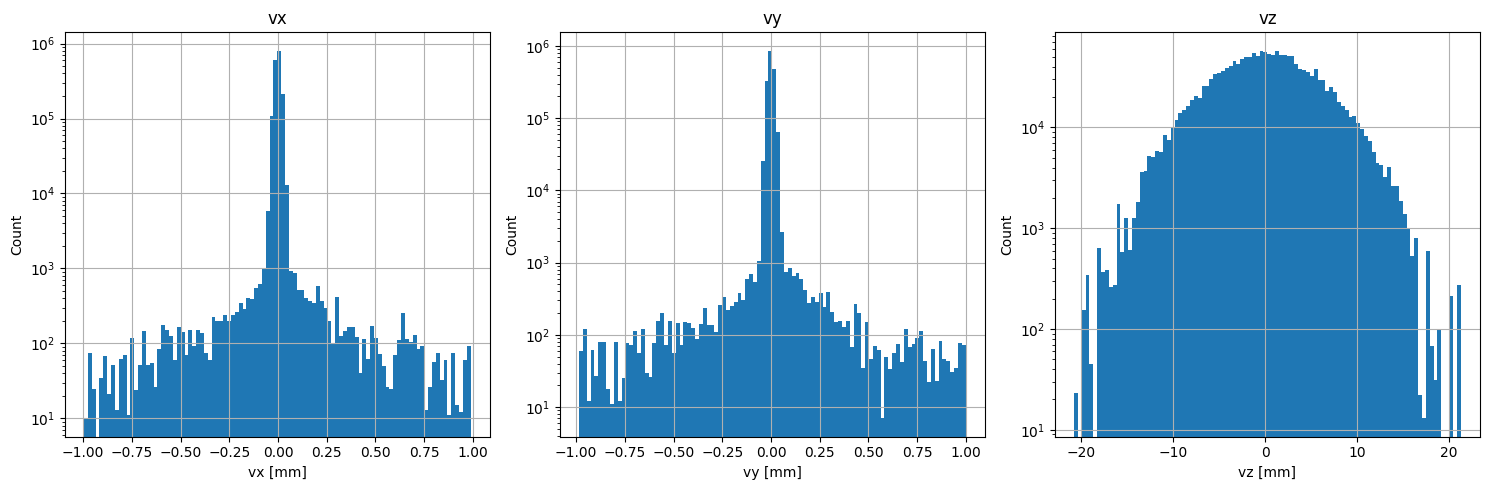

In [9]:
# Plot vx, vy, vz distributions for all events
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
all_events.hist(column=["vx", "vy", "vz"], bins=100, ax=ax)

# Set log scale for all the axes
for a in ax:
    a.set_yscale("log")
    a.set_ylabel("Count")

# Set x labels
ax[0].set_xlabel("vx [mm]")
ax[1].set_xlabel("vy [mm]")
ax[2].set_xlabel("vz [mm]")
plt.tight_layout()
plt.savefig("Results/TrackML/vx_vy_vz_no_secondaries_eta_inf_1.png")
plt.show()

In [35]:
from trackml.dataset import load_event
from trackml.utils import add_position_quantities, add_momentum_quantities, decode_particle_id

# get the particles data
(particles,) = load_event('Data/Tml/train_1/test/event000002643', parts=['particles'])
# decode particle id into vertex id, generation, etc.
particles = decode_particle_id(particles)
# print(particles)
sel = particles['secondary_id'] != 0
sel2 = particles['generation'] == 0
print(particles.columns)
print(np.unique(particles[sel]["generation"]))
print(np.unique(particles[~sel2]["secondary_id"]))
# print(np.unique(particles[~sel]["primary_id"]))
# print(np.unique(particles[sel]["primary_id"]))
# print(np.unique(particles[~sel]["primary_id"]))
# print(np.unique(particles[sel]["vertex_id"]))
# print(np.unique(particles[~sel]["vertex_id"]))

# # add vertex rho, phi, r
# particles = add_position_quantities(particles, prefix='v')
# # add momentum eta, p, pt
# particles = add_momentum_quantities(particles)

Index(['particle_id', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'q', 'nhits',
       'vertex_id', 'primary_id', 'generation', 'secondary_id', 'process'],
      dtype='object')
[1 2 3]
[1 2 3 4 5 6 7 8]


In [3]:
from trackml.dataset import load_dataset

print(list(load_dataset('Data/TrackML/training_part01.tar', nevents=2)))


BadZipFile: File is not a zip file